# Question Sampling for Human Study (Control Questions)

Goal: select a manageable subset of questions (~100–150) from the 1K VQA control set
that are most informative for human data collection.

## Sampling Criteria

| Tier | Criterion | Rationale |
|------|-----------|-----------|
| A | **Overconfident & Wrong** | High model confidence + low accuracy = hallucination signal |
| B | **Answer Flip across variants** | Model changes answer when question is weakened = genuine linguistic sensitivity |
| C | **Cross-model consensus wrong** | All models give same wrong answer = shared corpus prior |
| D | **High degradation** | Large accuracy drop from `question` → `pronominalized` = shortcut dependent |
| E | **Stratified by answer type** | Ensure coverage of yes/no, number, color, location, other |

Target: ~30 questions per tier, stratified by answer type, final deduplicated set of ~100–150.

In [1]:
import json
import pandas as pd
import numpy as np
import os
import sys
sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, vqa_accuracy

RESULTS_DIR    = '/home/david/Desktop/yuna/HPA/evaluation/logits/pretrained'
SEMANTICS_PATH = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl'

mapper = VQAAnswerMapper()

# 4 base degradation steps used for Tier B flip analysis
CONTROL_TYPES = ['question', 'deictic_removed', 'object_removed', 'weaker_object']
# Degradation endpoint for Tier D/E (full pronoun ablation — steepest drop)
ABLATED_KEY   = 'pronominalized'

# Models with complete vqa_1k_control.jsonl (all 4 CONTROL_TYPES keys, 1000 records).
# Pending (fix still running): llava-1.5-7b-hf, llava-v1.6-mistral-7b-hf, Qwen3-VL-8B-Instruct
COMPLETE_MODELS = [
    'llava-v1.6-vicuna-7b-hf',
    'llava-v1.6-vicuna-13b-hf',
    'Qwen3-VL-2B-Instruct',
    'Qwen3-VL-4B-Instruct',
]

sem_df = pd.read_json(SEMANTICS_PATH, lines=True)[['question_id', 'ent', 'w', 'op', 'attr', 'ans']]
qid_to_ent = dict(zip(sem_df['question_id'], sem_df['ent']))

In [2]:
def load_control(model, dataset='vqa_1k_control'):
    filepath = f'{RESULTS_DIR}/{model}/{dataset}.jsonl'
    if not os.path.exists(filepath):
        return []
    rows = []
    with open(filepath) as f:
        for line in f:
            ex = json.loads(line)
            if 'generated_logits' not in ex:
                continue
            gt_answers = mapper.get_answers(ex['question_id'])
            ent = qid_to_ent.get(ex['question_id'], 'other')
            for ct in ex['generated_logits']:
                logits = ex['generated_logits'][ct]['content']
                token_probs = np.exp([t['logprob'] for t in logits])
                confidence = float(token_probs.mean())
                output = (ex.get('generated_answers') or {}).get(ct, '')
                accuracy = vqa_accuracy(output, gt_answers) if gt_answers else None
                rows.append({
                    'model': model,
                    'question_id': ex['question_id'],
                    'control_type': ct,
                    'question_text': ex.get(ct, ''),
                    'output': output,
                    'confidence': confidence,
                    'accuracy': accuracy,
                    'ent': ent,
                    'gt_answer': gt_answers
                })
    return rows

all_rows = []
for m in COMPLETE_MODELS:
    rows = load_control(m)
    print(f"  {m}: {len(rows)} rows ({len(rows)//max(len(CONTROL_TYPES),1) if rows else 0} questions approx)")
    all_rows.extend(rows)

df = pd.DataFrame(all_rows)
df['accuracy'] = pd.to_numeric(df['accuracy'], errors='coerce')

# Keep base 4 control types + pronominalized (ablation endpoint); drop deprecated subject_ablated
LOAD_TYPES = CONTROL_TYPES + ([ABLATED_KEY] if ABLATED_KEY not in CONTROL_TYPES else [])
df = df[df['control_type'].isin(LOAD_TYPES)]

print(f'\nTotal: {len(df)} rows | {df["model"].nunique()} models | {df["question_id"].nunique()} questions')
print(f'Control types loaded: {sorted(df["control_type"].unique())}')
print(f'\nModel × question coverage:')
print(df[df["control_type"]=="question"].groupby("model")["question_id"].nunique())

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...


   ✓ Loaded 214354 VQA annotations
  llava-v1.6-vicuna-7b-hf: 6000 rows (1500 questions approx)


  llava-v1.6-vicuna-13b-hf: 5000 rows (1250 questions approx)
  Qwen3-VL-2B-Instruct: 5910 rows (1477 questions approx)


  Qwen3-VL-4B-Instruct: 6000 rows (1500 questions approx)

Total: 18928 rows | 4 models | 1000 questions
Control types loaded: ['deictic_removed', 'object_removed', 'pronominalized', 'question', 'weaker_object']

Model × question coverage:
model
Qwen3-VL-2B-Instruct         982
Qwen3-VL-4B-Instruct        1000
llava-v1.6-vicuna-13b-hf    1000
llava-v1.6-vicuna-7b-hf     1000
Name: question_id, dtype: int64


In [3]:
# Model coverage summary
print("=== Model Coverage (vqa_1k_control) ===")
print("\nCOMPLETE (in current analysis):")
for m in COMPLETE_MODELS:
    print(f"  ✓ {m}")
print("\nPENDING (fix/inference running — will add when complete):")
for m in ['llava-1.5-7b-hf', 'llava-v1.6-mistral-7b-hf', 'Qwen3-VL-8B-Instruct', 'Qwen3-VL-2B-Instruct (blind/inst_blind)']:
    print(f"  ◷ {m}")

print(f"\nNew vs previous analysis:")
print(f"  Removed: Qwen3-VL-32B-Instruct (only 43/1000 records), Qwen3-VL-8B-Instruct (incomplete)")
print(f"  Added:   Qwen3-VL-2B-Instruct, Qwen3-VL-4B-Instruct (both fully complete for _control)")
print(f"  Added:   llava-v1.6-vicuna-13b-hf (has all 4 CONTROL_TYPES keys)")

=== Model Coverage (vqa_1k_control) ===

COMPLETE (in current analysis):
  ✓ llava-v1.6-vicuna-7b-hf
  ✓ llava-v1.6-vicuna-13b-hf
  ✓ Qwen3-VL-2B-Instruct
  ✓ Qwen3-VL-4B-Instruct

PENDING (fix/inference running — will add when complete):
  ◷ llava-1.5-7b-hf
  ◷ llava-v1.6-mistral-7b-hf
  ◷ Qwen3-VL-8B-Instruct
  ◷ Qwen3-VL-2B-Instruct (blind/inst_blind)

New vs previous analysis:
  Removed: Qwen3-VL-32B-Instruct (only 43/1000 records), Qwen3-VL-8B-Instruct (incomplete)
  Added:   Qwen3-VL-2B-Instruct, Qwen3-VL-4B-Instruct (both fully complete for _control)
  Added:   llava-v1.6-vicuna-13b-hf (has all 4 CONTROL_TYPES keys)


In [ ]:
# Aggregate per (question_id, control_type) across all complete models
agg = df.groupby(['question_id', 'control_type', 'ent']).agg(
    mean_accuracy=('accuracy', 'mean'),
    mean_confidence=('confidence', 'mean'),
    n_models=('model', 'nunique'),
    outputs=('output', lambda x: list(x)),
).reset_index()

baseline = agg[agg['control_type'] == 'question'][['question_id', 'mean_accuracy', 'mean_confidence', 'ent']]
baseline.columns = ['question_id', 'acc_baseline', 'conf_baseline', 'ent']
ablated = agg[agg['control_type'] == ABLATED_KEY][['question_id', 'mean_accuracy', 'mean_confidence']]
ablated.columns = ['question_id', 'acc_ablated', 'conf_ablated']

qdf = baseline.merge(ablated, on='question_id')
qdf['acc_drop']  = qdf['acc_baseline'] - qdf['acc_ablated']
qdf['conf_drop'] = qdf['conf_baseline'] - qdf['conf_ablated']

# Tier A — overconfident & wrong
qdf['overconfident_wrong'] = (qdf['conf_baseline'] > 0.75) & (qdf['acc_baseline'] < 0.2)

# Tier B — answer flip across control variants
flip = df[df['control_type'].isin(CONTROL_TYPES)].groupby(['question_id', 'model']).apply(
    lambda g: g.set_index('control_type')['output'].reindex(CONTROL_TYPES).nunique(dropna=True)
).reset_index()
flip.columns = ['question_id', 'model', 'n_unique_outputs']
flip_agg = flip.groupby('question_id')['n_unique_outputs'].mean().reset_index()
flip_agg.columns = ['question_id', 'mean_output_changes']

# Tier C — majority of models wrong on baseline
consensus = (
    df[df['control_type'] == 'question']
    .groupby('question_id')
    .apply(lambda g: (g['accuracy'] < 0.2).mean())
    .reset_index()
)
consensus.columns = ['question_id', 'frac_models_wrong']
consensus['consensus_wrong'] = consensus['frac_models_wrong'] >= 0.8

qdf = qdf.merge(flip_agg, on='question_id').merge(
    consensus[['question_id', 'consensus_wrong', 'frac_models_wrong']], on='question_id'
)

# ── Compute n_distinct (flat question filter) ────────────────────────────────
CONTROL_PATH = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_control.jsonl'
CT5 = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']

nd_rows = []
with open(CONTROL_PATH) as f:
    for line in f:
        ex = json.loads(line)
        texts = {ex.get(ct, '').strip().lower() for ct in CT5 if ex.get(ct, '').strip()}
        nd_rows.append({'question_id': ex['question_id'], 'n_distinct': len(texts)})
nd_df = pd.DataFrame(nd_rows)

qdf = qdf.merge(nd_df, on='question_id', how='left')
qdf['n_distinct'] = qdf['n_distinct'].fillna(-1).astype(int)

# Save full qdf before filtering so we can show tier impact
qdf_all = qdf.copy()
flat_ids = set(qdf[qdf['n_distinct'] == 1]['question_id'])

# Remove flat questions from all sampling pools
qdf = qdf[qdf['n_distinct'] > 1].copy()

print(f"Loaded {len(qdf_all)} questions | {df['model'].nunique()} models: {sorted(df['model'].unique())}")
print(f"Degradation endpoint: '{ABLATED_KEY}'")
print(f"\nFlat questions removed (all 5 CTs identical): {len(flat_ids)}")
print(f"Remaining for sampling: {len(qdf)}")
qdf.head()

In [ ]:
print('=== Tier Pool Sizes — Before vs After Flat Removal ===\n')
tier_masks = {
    'A  overconfident & wrong  (conf>0.75, acc<0.2)':
        ('overconfident_wrong',      lambda q: q['overconfident_wrong']),
    'B  answer flip  (mean unique > 2)':
        ('mean_output_changes>2',    lambda q: q['mean_output_changes'] > 2),
    'C  consensus wrong  (≥80% models)':
        ('consensus_wrong',          lambda q: q['consensus_wrong']),
    'D  high acc drop  (>0.3)':
        ('acc_drop>0.3',             lambda q: q['acc_drop'] > 0.3),
    'E  high conf drop (>0.05, acc>0.5)':
        ('conf_drop>0.05',           lambda q: (q['conf_drop'] > 0.05) & (q['acc_baseline'] > 0.5)),
}

for label, (_, mask_fn) in tier_masks.items():
    n_before = mask_fn(qdf_all).sum()
    n_after  = mask_fn(qdf).sum()
    n_flat   = n_before - n_after
    pct      = n_flat / n_before * 100 if n_before > 0 else 0
    flag     = '  ← notable' if pct >= 5 else ''
    print(f'  Tier {label}')
    print(f'    before: {n_before:4d}  after: {n_after:4d}  flat removed: {n_flat} ({pct:.1f}%){flag}')
    print()

print(f'Total flat removed: {len(flat_ids)} / {len(qdf_all)} ({len(flat_ids)/len(qdf_all)*100:.1f}%)')
print(f'Sampling pool size: {len(qdf)}')
print()
print('=== Criterion Counts (flat-filtered pool) ===')
print(f"A. Overconfident & Wrong (conf>0.75, acc<0.2):        {qdf['overconfident_wrong'].sum()}")
print(f"B. Answer flip (mean unique outputs > 2):             {(qdf['mean_output_changes'] > 2).sum()}")
print(f"C. Consensus wrong (≥80% models wrong on baseline):  {qdf['consensus_wrong'].sum()}")
print(f"D. High accuracy drop (acc_drop > 0.3):              {(qdf['acc_drop'] > 0.3).sum()}")
print(f"E. High confidence drop (conf_drop > 0.05, acc>0.5): {((qdf['conf_drop'] > 0.05) & (qdf['acc_baseline'] > 0.5)).sum()}")
print()
print('Entity distribution (flat-filtered):')
print(qdf['ent'].value_counts())

import matplotlib.pyplot as plt
drop_label = f'question → {ABLATED_KEY}'
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(qdf['acc_drop'], qdf['conf_drop'], alpha=0.3, s=10)
axes[0].axhline(0.05, color='r', linestyle='--', label='conf_drop threshold')
axes[0].axvline(0.3, color='b', linestyle='--', label='acc_drop threshold')
axes[0].set_xlabel(f'Accuracy drop ({drop_label})')
axes[0].set_ylabel(f'Confidence drop ({drop_label})')
axes[0].set_title('Accuracy vs Confidence Drop\n(flat questions excluded)')
axes[0].legend(fontsize=8)

axes[1].scatter(qdf['acc_baseline'], qdf['conf_drop'], alpha=0.3, s=10,
                c=qdf['conf_baseline'], cmap='RdYlGn')
axes[1].axhline(0.05, color='r', linestyle='--')
axes[1].set_xlabel('Baseline accuracy')
axes[1].set_ylabel(f'Confidence drop ({drop_label})')
axes[1].set_title('Baseline Accuracy vs Confidence Drop\n(color = baseline confidence; flat excluded)')
plt.tight_layout()
plt.show()

In [6]:
np.random.seed(42)

N_PER_TIER = 30

def stratified_sample(mask, n, ent_col='ent', seed=42):
    """Sample n questions from mask, stratified by entity group."""
    pool = qdf[mask].copy()
    if len(pool) == 0:
        print("  → empty pool, skipping")
        return []
    counts = pool[ent_col].value_counts(normalize=True)
    sampled = []
    for ent, frac in counts.items():
        k = max(1, round(n * frac))
        sub = pool[pool[ent_col] == ent]
        sampled.extend(sub.sample(min(k, len(sub)), random_state=seed)['question_id'].tolist())
    return list(set(sampled))[:n]

tier_A = stratified_sample(qdf['overconfident_wrong'],        N_PER_TIER)
tier_B = stratified_sample(qdf['mean_output_changes'] > 2,    N_PER_TIER)
tier_C = stratified_sample(qdf['consensus_wrong'],            N_PER_TIER)
tier_D = stratified_sample(qdf['acc_drop'] > 0.3,            N_PER_TIER)
tier_E = stratified_sample(qdf['conf_drop'] > 0.05,          N_PER_TIER)

# Combine, deduplicate, label tiers
all_sampled = {}
for qid in tier_A: all_sampled[qid] = all_sampled.get(qid, []) + ['A_overconfident_wrong']
for qid in tier_B: all_sampled[qid] = all_sampled.get(qid, []) + ['B_answer_flip']
for qid in tier_C: all_sampled[qid] = all_sampled.get(qid, []) + ['C_consensus_wrong']
for qid in tier_D: all_sampled[qid] = all_sampled.get(qid, []) + ['D_high_acc_drop']
for qid in tier_E: all_sampled[qid] = all_sampled.get(qid, []) + ['E_high_conf_drop']

sampled_df = pd.DataFrame([
    {'question_id': qid, 'tiers': '|'.join(tiers)}
    for qid, tiers in all_sampled.items()
])
sampled_df = sampled_df.merge(qdf, on='question_id')
sampled_df['n_tiers'] = sampled_df['tiers'].str.count(r'\|') + 1
sampled_df = sampled_df.sort_values('n_tiers', ascending=False)

print(f'Total unique questions selected: {len(sampled_df)}')
print(f'Questions in multiple tiers:     {(sampled_df["n_tiers"] > 1).sum()}')
print()
print('Entity distribution in sample:')
print(sampled_df['ent'].value_counts())
print()
print('Tier breakdown:')
for tier in ['A_overconfident_wrong', 'B_answer_flip', 'C_consensus_wrong', 'D_high_acc_drop', 'E_high_conf_drop']:
    print(f'  {tier}: {sampled_df["tiers"].str.contains(tier).sum()}')


Total unique questions selected: 130
Questions in multiple tiers:     19

Entity distribution in sample:
ent
object     61
person     19
food       13
animal     10
vehicle     7
other       7
place       6
text        4
product     3
Name: count, dtype: int64

Tier breakdown:
  A_overconfident_wrong: 30
  B_answer_flip: 30
  C_consensus_wrong: 30
  D_high_acc_drop: 30
  E_high_conf_drop: 30


## Research Context: Hallucination & Shortcut Tiers

**HPA question:** Do VLMs hallucinate answers from corpus priors, or are responses grounded in visual input?

To probe this, we evaluate models **text-only** (no image) across a degradation ladder of 5 control variants that progressively strip referential anchors:

> **Original → Deictic Removed → Object Removed → Weaker Object → Subject Ablated**

Each tier captures a distinct failure mode:

| Tier | Criterion | Failure Mode | Research Signal |
|------|-----------|--------------|-----------------|
| **A** | conf > 0.75, acc < 0.2 | **Hallucination** | Model confidently generates wrong answer from text priors |
| **B** | Mean output diversity > 2 across variants | **Linguistic shortcut** | Answer triggered by specific phrasing, not content |
| **C** | ≥ 80% models wrong (same answer) | **Shared corpus prior** | Training statistics bias all models identically |
| **D** | Accuracy drop > 0.3 (original → ablated) | **Shortcut dependency** | Model needs full referential structure to recall correct answer |
| **E** | Confidence drop > 0.05 | **Calibration artifact** | Confidence tracks surface cues, not semantic understanding |

Questions appearing in **3+ tiers** (gold questions) simultaneously probe multiple failure modes and provide the richest signal for human study design.

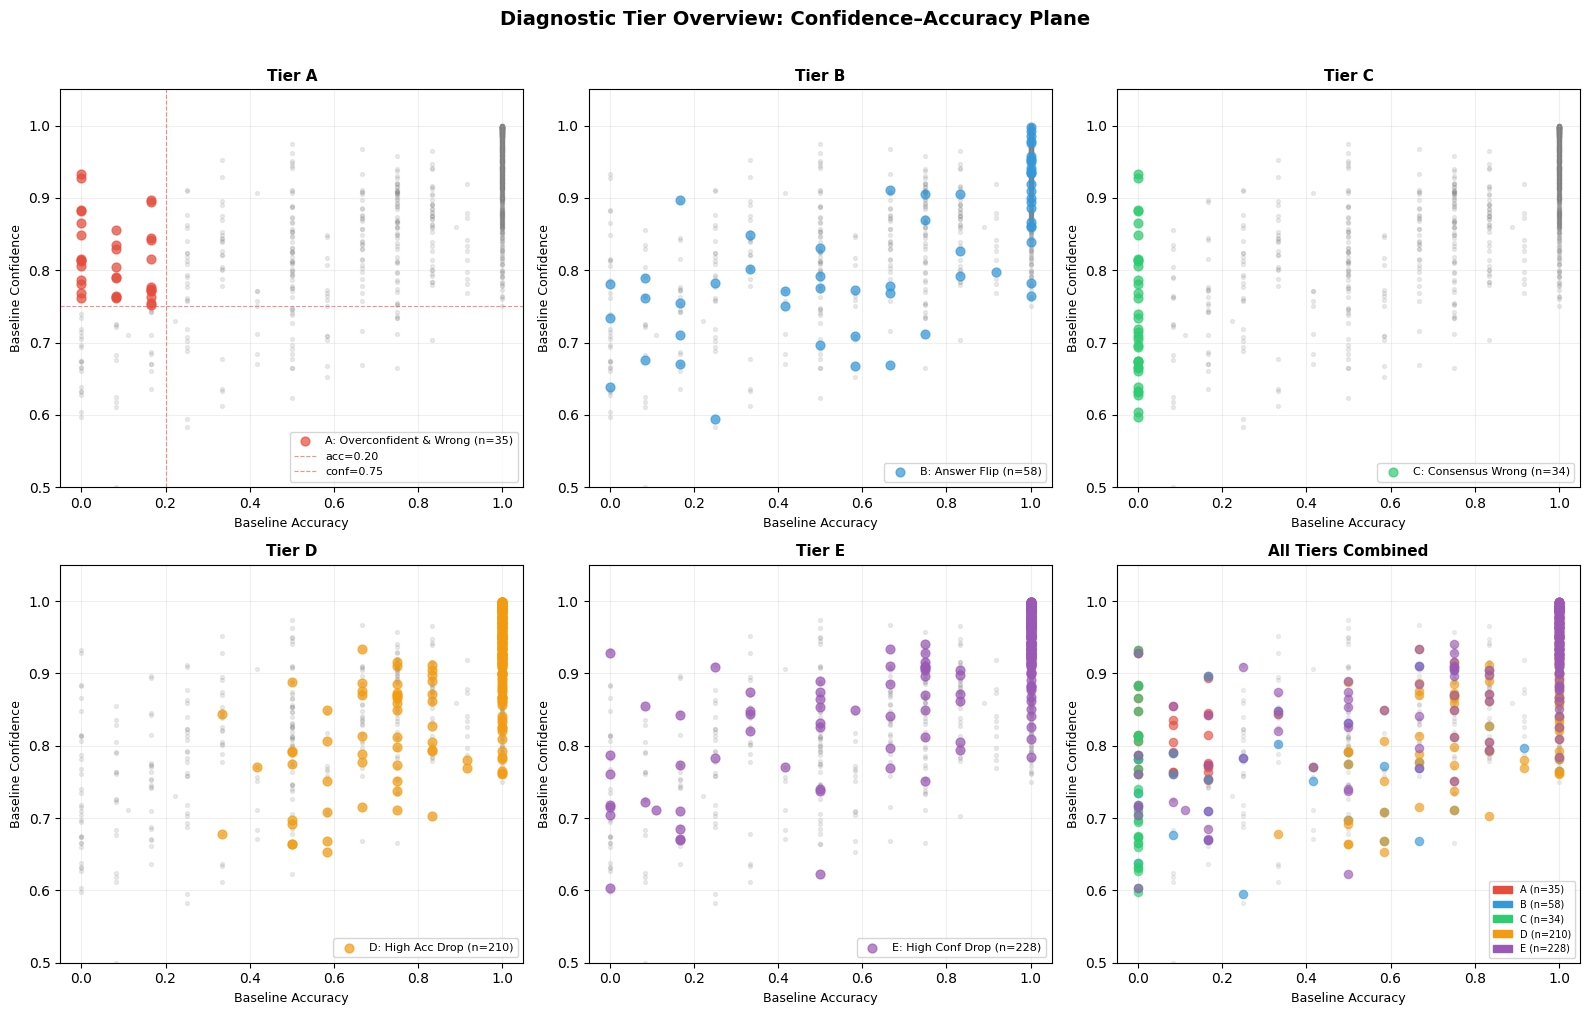

Spatial patterns in the confidence–accuracy plane:
  Tier A (red):    Top-left corner — high confidence, low accuracy = hallucination zone
  Tier C (green):  Left cluster — all models wrong, regardless of confidence level
  Tier B (blue):   Scattered across plane — answer flip is independent of absolute accuracy


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

FIGURES_DIR = '/home/david/Desktop/yuna/HPA/analysis/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

tier_info = {
    'A': {'mask': qdf['overconfident_wrong'],          'color': '#e74c3c', 'label': 'A: Overconfident & Wrong'},
    'B': {'mask': qdf['mean_output_changes'] > 2,      'color': '#3498db', 'label': 'B: Answer Flip'},
    'C': {'mask': qdf['consensus_wrong'],               'color': '#2ecc71', 'label': 'C: Consensus Wrong'},
    'D': {'mask': qdf['acc_drop'] > 0.3,               'color': '#f39c12', 'label': 'D: High Acc Drop'},
    'E': {'mask': qdf['conf_drop'] > 0.05,             'color': '#9b59b6', 'label': 'E: High Conf Drop'},
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Diagnostic Tier Overview: Confidence–Accuracy Plane', fontsize=14, fontweight='bold', y=1.01)
axes_flat = axes.flatten()

for idx, (tier_key, info) in enumerate(tier_info.items()):
    ax = axes_flat[idx]
    # Background: all 1K questions
    ax.scatter(qdf['acc_baseline'], qdf['conf_baseline'], s=8, alpha=0.15, color='gray', zorder=1)
    # Highlighted tier
    subset = qdf[info['mask']]
    ax.scatter(subset['acc_baseline'], subset['conf_baseline'],
               s=40, alpha=0.7, color=info['color'], zorder=2,
               label=f"{info['label']} (n={len(subset)})")
    # Tier A thresholds
    if tier_key == 'A':
        ax.axvline(0.2, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.6, label='acc=0.20')
        ax.axhline(0.75, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.6, label='conf=0.75')
    ax.set_xlabel('Baseline Accuracy', fontsize=9)
    ax.set_ylabel('Baseline Confidence', fontsize=9)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_title(f'Tier {tier_key}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.2)

# Combined panel
ax_all = axes_flat[5]
ax_all.scatter(qdf['acc_baseline'], qdf['conf_baseline'], s=8, alpha=0.12, color='gray', zorder=1)
handles = []
for tier_key, info in tier_info.items():
    subset = qdf[info['mask']]
    ax_all.scatter(subset['acc_baseline'], subset['conf_baseline'],
                   s=35, alpha=0.6, color=info['color'], zorder=2)
    handles.append(mpatches.Patch(color=info['color'], label=f"{info['label'].split(':')[0]} (n={len(subset)})"))
ax_all.set_xlabel('Baseline Accuracy', fontsize=9)
ax_all.set_ylabel('Baseline Confidence', fontsize=9)
ax_all.set_xlim(-0.05, 1.05)
ax_all.set_ylim(0.5, 1.05)
ax_all.legend(handles=handles, fontsize=7, loc='lower right')
ax_all.set_title('All Tiers Combined', fontsize=11, fontweight='bold')
ax_all.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/tier_overview_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Spatial patterns in the confidence–accuracy plane:")
print("  Tier A (red):    Top-left corner — high confidence, low accuracy = hallucination zone")
print("  Tier C (green):  Left cluster — all models wrong, regardless of confidence level")
print("  Tier B (blue):   Scattered across plane — answer flip is independent of absolute accuracy")


In [8]:
# Build review_df: one row per question with per-model outputs for baseline ('question' variant)
model_outputs = df[df['control_type'] == 'question'].pivot_table(
    index='question_id', columns='model', values='output', aggfunc='first'
).reset_index()

review_df = qdf.merge(model_outputs, on='question_id')
review_df = review_df.merge(
    df[df['control_type'] == 'question'][['question_id', 'question_text', 'gt_answer']].drop_duplicates('question_id'),
    on='question_id'
)

MODEL_COLS = sorted(df['model'].unique().tolist())

def clean_q(s):
    s = str(s)
    for strip in ['Question: ', ' Answer the question using a single word or phrase.', '\nAnswer:']:
        s = s.replace(strip, '')
    return s.strip()[:90]

def fmt_gt(gt):
    if isinstance(gt, list):
        unique = list(dict.fromkeys(str(a) for a in gt))
        return ', '.join(unique[:3]) + ('…' if len(unique) > 3 else '')
    return str(gt)[:40]

# Tier A: top 6 by confidence
tier_a_ids = sampled_df[sampled_df['tiers'].str.contains('A_')]['question_id'].tolist()
tier_a_df  = review_df[review_df['question_id'].isin(tier_a_ids)].sort_values('conf_baseline', ascending=False).head(6)

display_a = tier_a_df[['question_id', 'ent', 'conf_baseline', 'acc_baseline', 'question_text', 'gt_answer'] + MODEL_COLS].copy()
display_a['Q']        = display_a['question_text'].apply(clean_q)
display_a['GT']       = display_a['gt_answer'].apply(fmt_gt)
display_a = display_a[['question_id', 'ent', 'Q', 'GT', 'conf_baseline', 'acc_baseline'] + MODEL_COLS]

from IPython.display import display as ipy_display
styled = (display_a.style
    .background_gradient(subset=['conf_baseline'], cmap='Reds',   vmin=0.5, vmax=1.0)
    .background_gradient(subset=['acc_baseline'],  cmap='Greens', vmin=0.0, vmax=1.0)
    .format({'conf_baseline': '{:.3f}', 'acc_baseline': '{:.3f}'})
    .set_caption('Tier A — Overconfident & Wrong (top 6 by confidence, 4-model ensemble)')
)
ipy_display(styled)

,question_id,ent,Q,GT,conf_baseline,acc_baseline,Qwen3-VL-2B-Instruct,Qwen3-VL-4B-Instruct,llava-v1.6-vicuna-13b-hf,llava-v1.6-vicuna-7b-hf
496,286450002,object,What is the date of this photo?,"7/20/2010, 7/20/2013, 20-7-2012…",0.933,0.000,20.7.2013,20 7 2013,20.7.2013,2013
273,158279002,text,What is the web address listed?,"foodiebakercom, http://foodiebakercom",0.928,0.000,http://foodiebaker.com,HTTP://FOODIEBAKER.COM,Wwwfoodiebakercom,Wwwfoodiebakercom
26,13546003,object,How many benches are in the background?,"4, 3, 0…",0.897,0.167,2,3,2,2
211,126583001,person,What does the man have in his right hand?,"towel, tennis racquet, glove…",0.894,0.167,tennis racket,tennis racket,Racket,Racket
361,212759007,object,Is there a check mark here?,yes,0.884,0.000,no,no,No,No
909,525021007,person,Does everyone have helmets on?,yes,0.882,0.000,nan,no,No,No


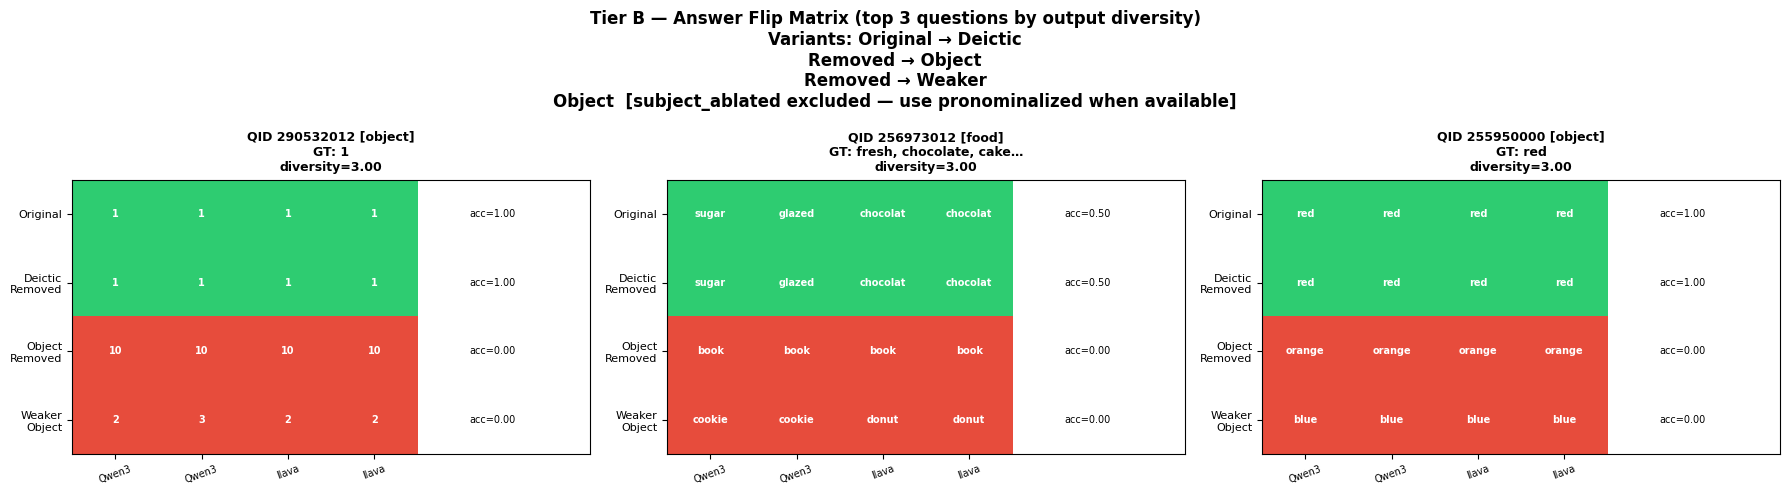

Insight: Answer changes when linguistic triggers are removed reveal that models respond
to question surface form, not semantic content. Green = matches baseline; red = flipped answer.

Note: subject_ablated excluded. Re-run with pronominalized once inference is complete.


In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

CT_LABELS = {
    'question':        'Original',
    'deictic_removed': 'Deictic\nRemoved',
    'object_removed':  'Object\nRemoved',
    'weaker_object':   'Weaker\nObject',
    # subject_ablated removed — deprecated; pronominalized not yet available
}
# Use CONTROL_TYPES from cell 1 (excludes subject_ablated)

# Top 3 Tier B questions by mean_output_changes
tier_b_ids = sampled_df[sampled_df['tiers'].str.contains('B_')].sort_values(
    'mean_output_changes', ascending=False)['question_id'].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Tier B — Answer Flip Matrix (top 3 questions by output diversity)\n'
             f'Variants: {" → ".join(CT_LABELS.values())}  [subject_ablated excluded — use pronominalized when available]',
             fontsize=12, fontweight='bold')

for ax_idx, qid in enumerate(tier_b_ids):
    ax = axes[ax_idx]
    
    # Baseline answer (from review_df)
    baseline_row = review_df[review_df['question_id'] == qid].iloc[0]
    baseline_answers = {m: str(baseline_row.get(m, '')).lower().strip() for m in MODEL_COLS}
    
    # Per-variant outputs from df — filter to current CONTROL_TYPES only
    q_data = df[
        (df['question_id'] == qid) &
        (df['model'].isin(MODEL_COLS)) &
        (df['control_type'].isin(CONTROL_TYPES))
    ].pivot_table(
        index='control_type', columns='model', values='output', aggfunc='first'
    ).reindex(CONTROL_TYPES)
    
    # Per-variant accuracy from agg
    acc_data = agg[(agg['question_id'] == qid)].set_index('control_type')['mean_accuracy'].reindex(CONTROL_TYPES)
    
    n_ct = len(CONTROL_TYPES)
    n_m  = len(MODEL_COLS)
    color_matrix = np.zeros((n_ct, n_m))
    text_matrix  = []
    
    for r, ct in enumerate(CONTROL_TYPES):
        row_texts = []
        for c, m in enumerate(MODEL_COLS):
            if ct in q_data.index and m in q_data.columns:
                val = str(q_data.loc[ct, m]).lower().strip() if pd.notna(q_data.loc[ct, m]) else ''
            else:
                val = ''
            base_ans = baseline_answers.get(m, '')
            color_matrix[r, c] = 1.0 if (val == base_ans and val != '') else 0.0
            row_texts.append(val[:8])
        text_matrix.append(row_texts)
    
    # Heatmap: green=matches baseline, red=different
    cmap = mcolors.LinearSegmentedColormap.from_list('flip', ['#e74c3c', '#2ecc71'])
    ax.imshow(color_matrix, cmap=cmap, vmin=0, vmax=1, aspect='auto')
    
    for r in range(n_ct):
        for c in range(n_m):
            ax.text(c, r, text_matrix[r][c], ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')
        # Right-margin acc annotation
        acc_val = acc_data.iloc[r] if r < len(acc_data) else float('nan')
        ax.text(n_m + 0.1, r, f'acc={acc_val:.2f}' if pd.notna(acc_val) else 'acc=N/A',
                va='center', fontsize=7, color='black')
    
    ax.set_xticks(range(n_m))
    ax.set_xticklabels([m.split('-')[0][:12] for m in MODEL_COLS], fontsize=7, rotation=20)
    ax.set_yticks(range(n_ct))
    ax.set_yticklabels([CT_LABELS[ct] for ct in CONTROL_TYPES], fontsize=8)
    ax.set_xlim(-0.5, n_m + 1.5)
    
    # Entity and GT
    row_info = sampled_df[sampled_df['question_id'] == qid].iloc[0]
    gt_sample = fmt_gt(baseline_row['gt_answer'])
    diversity = row_info['mean_output_changes']
    ax.set_title(f'QID {qid} [{row_info["ent"]}]\nGT: {gt_sample}\ndiversity={diversity:.2f}',
                 fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/tier_b_flip_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: Answer changes when linguistic triggers are removed reveal that models respond")
print("to question surface form, not semantic content. Green = matches baseline; red = flipped answer.")
print(f"\nNote: subject_ablated excluded. Re-run with pronominalized once inference is complete.")

ValueError: could not convert string to float: '100%'

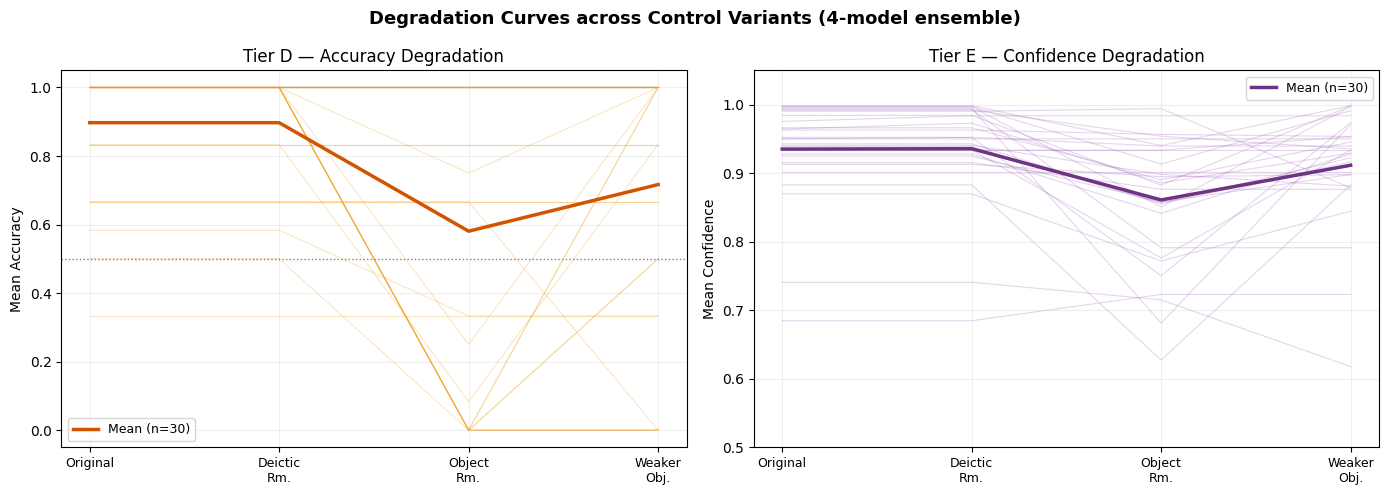

In [10]:
import matplotlib.pyplot as plt
from IPython.display import display as ipy_display

CT_AXIS_LABELS = ['Original', 'Deictic\nRm.', 'Object\nRm.', 'Weaker\nObj.']
x = range(len(CONTROL_TYPES))

# ── Tier C: top 6 by frac_models_wrong ──────────────────────────────────────
tier_c_ids = sampled_df[sampled_df['tiers'].str.contains('C_')].sort_values(
    'frac_models_wrong', ascending=False)['question_id'].head(6).tolist()
tier_c_df = review_df[review_df['question_id'].isin(tier_c_ids)].sort_values('frac_models_wrong', ascending=False)

display_c = tier_c_df[['question_id', 'ent', 'question_text', 'gt_answer', 'frac_models_wrong'] + MODEL_COLS].copy()
display_c['Q']      = display_c['question_text'].apply(clean_q)
display_c['GT']     = display_c['gt_answer'].apply(fmt_gt)
display_c['% wrong'] = display_c['frac_models_wrong'].map('{:.0%}'.format)
ipy_display(display_c[['question_id', 'ent', 'Q', 'GT', '% wrong'] + MODEL_COLS].style
    .background_gradient(subset=['% wrong'], cmap='Reds')
    .set_caption('Tier C — Cross-Model Consensus Wrong (top 6)'))

# ── Tier D & E: Degradation Curves ──────────────────────────────────────────
fig, (ax_d, ax_e) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Degradation Curves across Control Variants (4-model ensemble)', fontsize=13, fontweight='bold')

# Tier D — accuracy
tier_d_ids = sampled_df[sampled_df['tiers'].str.contains('D_')]['question_id'].tolist()
tier_d_curves = []
for qid in tier_d_ids:
    q_agg = agg[(agg['question_id'] == qid)].set_index('control_type')['mean_accuracy'].reindex(CONTROL_TYPES)
    if q_agg.notna().sum() >= 3:
        tier_d_curves.append(q_agg.values)
        ax_d.plot(x, q_agg.values, color='#f39c12', alpha=0.25, linewidth=0.8)
if tier_d_curves:
    mean_d = np.nanmean(tier_d_curves, axis=0)
    ax_d.plot(x, mean_d, color='#d35400', linewidth=2.5, label=f'Mean (n={len(tier_d_curves)})', zorder=5)
ax_d.axhline(0.5, color='gray', linestyle=':', linewidth=1)
ax_d.set_xticks(list(x)); ax_d.set_xticklabels(CT_AXIS_LABELS, fontsize=9)
ax_d.set_ylabel('Mean Accuracy'); ax_d.set_ylim(-0.05, 1.05)
ax_d.set_title('Tier D — Accuracy Degradation'); ax_d.legend(fontsize=9); ax_d.grid(True, alpha=0.2)

# Tier E — confidence
tier_e_ids = sampled_df[sampled_df['tiers'].str.contains('E_')]['question_id'].tolist()
tier_e_curves = []
for qid in tier_e_ids:
    q_agg = agg[(agg['question_id'] == qid)].set_index('control_type')['mean_confidence'].reindex(CONTROL_TYPES)
    if q_agg.notna().sum() >= 3:
        tier_e_curves.append(q_agg.values)
        ax_e.plot(x, q_agg.values, color='#9b59b6', alpha=0.25, linewidth=0.8)
if tier_e_curves:
    mean_e = np.nanmean(tier_e_curves, axis=0)
    ax_e.plot(x, mean_e, color='#6c3483', linewidth=2.5, label=f'Mean (n={len(tier_e_curves)})', zorder=5)
ax_e.set_xticks(list(x)); ax_e.set_xticklabels(CT_AXIS_LABELS, fontsize=9)
ax_e.set_ylabel('Mean Confidence'); ax_e.set_ylim(0.5, 1.05)
ax_e.set_title('Tier E — Confidence Degradation'); ax_e.legend(fontsize=9); ax_e.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/tier_d_e_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

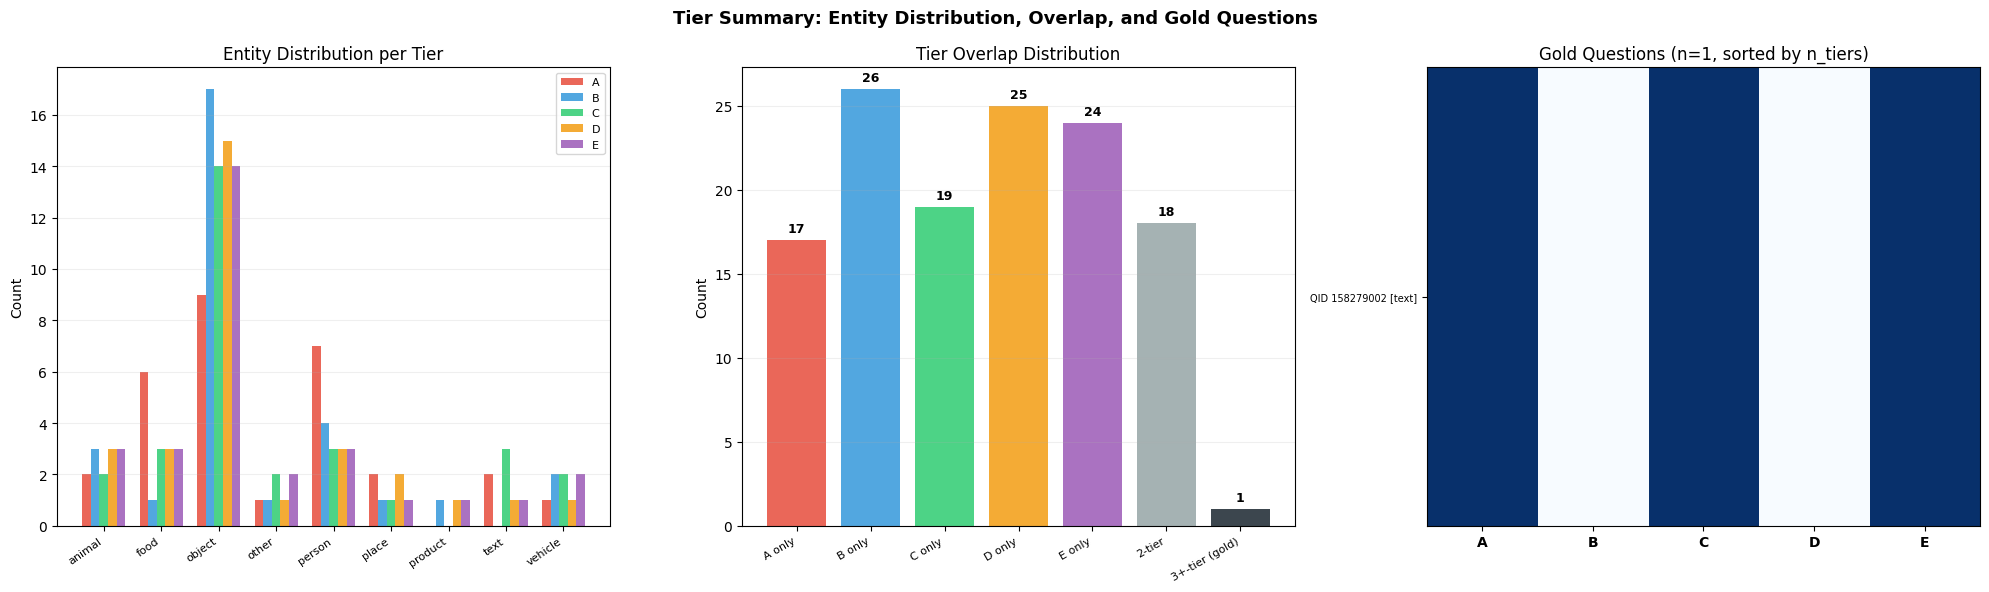

Gold questions (3+ tiers): 1
Gold questions should be prioritized for the human study — they simultaneously probe
multiple failure modes and provide the richest signal about whether humans share the
model's biases.


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

TIER_KEYS  = ['A', 'B', 'C', 'D', 'E']
TIER_NAMES = {'A': 'A_overconfident_wrong', 'B': 'B_answer_flip', 'C': 'C_consensus_wrong',
              'D': 'D_high_acc_drop', 'E': 'E_high_conf_drop'}
TIER_COLORS = {'A': '#e74c3c', 'B': '#3498db', 'C': '#2ecc71', 'D': '#f39c12', 'E': '#9b59b6'}
ENT_CATS   = sorted(qdf['ent'].dropna().unique())

# ── Entity distribution per tier ─────────────────────────────────────────────
tier_ent = {}
for t in TIER_KEYS:
    name = TIER_NAMES[t]
    ids = sampled_df[sampled_df['tiers'].str.contains(name)]['question_id'].tolist()
    sub = sampled_df[sampled_df['question_id'].isin(ids)]
    tier_ent[t] = sub['ent'].value_counts().reindex(ENT_CATS, fill_value=0)

# ── Tier overlap ──────────────────────────────────────────────────────────────
overlap_counts = {'A only': 0, 'B only': 0, 'C only': 0, 'D only': 0, 'E only': 0,
                  '2-tier': 0, '3+-tier (gold)': 0}
for _, row in sampled_df.iterrows():
    n = row['n_tiers']
    if n == 1:
        t = row['tiers'].split('_')[0]
        overlap_counts[f'{t} only'] += 1
    elif n == 2:
        overlap_counts['2-tier'] += 1
    else:
        overlap_counts['3+-tier (gold)'] += 1

# ── Gold questions ────────────────────────────────────────────────────────────
gold_df = sampled_df[sampled_df['n_tiers'] >= 3].sort_values('n_tiers', ascending=False).head(20)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Tier Summary: Entity Distribution, Overlap, and Gold Questions',
             fontsize=13, fontweight='bold')

# Left — grouped bar chart
bar_width = 0.15
ent_x = np.arange(len(ENT_CATS))
for i, t in enumerate(TIER_KEYS):
    ax1.bar(ent_x + i * bar_width, tier_ent[t].values, width=bar_width,
            label=t, color=TIER_COLORS[t], alpha=0.85)
ax1.set_xticks(ent_x + bar_width * 2)
ax1.set_xticklabels(ENT_CATS, rotation=35, ha='right', fontsize=8)
ax1.set_ylabel('Count')
ax1.set_title('Entity Distribution per Tier')
ax1.legend(fontsize=8)
ax1.grid(True, axis='y', alpha=0.2)

# Middle — tier overlap bars
bar_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#95a5a6','#1a252f']
bars = ax2.bar(range(len(overlap_counts)), list(overlap_counts.values()),
               color=bar_colors, alpha=0.85)
for bar, val in zip(bars, overlap_counts.values()):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xticks(range(len(overlap_counts)))
ax2.set_xticklabels(list(overlap_counts.keys()), rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('Count')
ax2.set_title('Tier Overlap Distribution')
ax2.grid(True, axis='y', alpha=0.2)

# Right — gold question heatmap
tier_binary = np.zeros((len(gold_df), len(TIER_KEYS)))
for r_idx, (_, row) in enumerate(gold_df.iterrows()):
    for c_idx, t in enumerate(TIER_KEYS):
        if TIER_NAMES[t] in row['tiers']:
            tier_binary[r_idx, c_idx] = 1.0

ax3.imshow(tier_binary, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax3.set_xticks(range(len(TIER_KEYS)))
ax3.set_xticklabels(TIER_KEYS, fontsize=10, fontweight='bold')
ytick_labels = [f"QID {row['question_id']} [{row['ent']}]"
                for _, row in gold_df.iterrows()]
ax3.set_yticks(range(len(gold_df)))
ax3.set_yticklabels(ytick_labels, fontsize=7)
ax3.set_title(f'Gold Questions (n={len(gold_df)}, sorted by n_tiers)')
ax3.grid(False)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/tier_summary.png', dpi=150, bbox_inches='tight')
plt.show()

gold_count = overlap_counts['3+-tier (gold)']
print(f"Gold questions (3+ tiers): {gold_count}")
print("Gold questions should be prioritized for the human study — they simultaneously probe")
print("multiple failure modes and provide the richest signal about whether humans share the")
print("model's biases.")


In [12]:
# Export for manual review / human study design
out_path = '/home/david/Desktop/yuna/HPA/analysis/csv/sampled_control_questions.csv'
review_df.to_csv(out_path, index=False)
print(f'Saved {len(review_df)} questions to {out_path}') 

Saved 1000 questions to /home/david/Desktop/yuna/HPA/analysis/csv/sampled_control_questions.csv


---
## Inference Results Summary (Updated)

### Model Status

| Model | `_control` | `_control_blind` | `_control_inst_blind` | In analysis |
|-------|-----------|-----------------|----------------------|-------------|
| llava-v1.6-vicuna-7b-hf | ✅ 1000 (FULL) | ✅ 1000 | ✅ 1000 | ✅ |
| llava-v1.6-vicuna-13b-hf | ✅ 1000 (BASE4) | ❌ missing | ✅ 1000 | ✅ |
| Qwen3-VL-2B-Instruct | ✅ 1000 (FULL) | ⚠️ 15 (fix needed) | ✅ 1000 | ✅ |
| Qwen3-VL-4B-Instruct | ✅ 1000 (FULL) | ◷ 1000 pron-only | ✅ 1000 | ✅ |
| llava-1.5-7b-hf | ◷ pron-only (fix running) | ✅ 1000 | ✅ 1000 | ◷ pending |
| llava-v1.6-mistral-7b-hf | ◷ pron-only (fix running) | ✅ 1000 | ✅ 1000 | ◷ pending |
| Qwen3-VL-8B-Instruct | ◷ pron-only (fix running) | ◷ 298/1000 | ◷ 994/1000 | ◷ pending |

FULL = all 5 keys (question, deictic_removed, object_removed, weaker_object, pronominalized).  
BASE4 = original 4 keys only (pronominalized not yet generated).

### What Changed vs Previous Analysis
- **Removed**: Qwen3-VL-32B (43/1000 records) and Qwen3-VL-8B (incomplete _control)
- **Added**: Qwen3-VL-2B-Instruct and Qwen3-VL-4B-Instruct (Qwen family size diversity)
- **Added**: llava-v1.6-vicuna-13b-hf (was missing from previous per_question aggregation)
- **Model ensemble**: 2 LLaVA (vicuna-7b + vicuna-13b) + 2 Qwen (2B + 4B) = balanced size diversity

### New `pronominalized` control type
Degradation ladder: `question → deictic_removed → object_removed → weaker_object → pronominalized`

Replaces deprecated `subject_ablated` with grammar-aware pronoun substitution  
(e.g. "What color is the dog?" → "What color is it?").  
Will be added to `CONTROL_TYPES` and `ABLATED_KEY` once all 4 models have it (pending vicuna-13b).

---

## Human Study v2 — Balanced Sampling (350 questions, blind condition)

The 123-question tier-based sample above was designed for control-question analysis.
For the actual human study we need a larger, **ent/op-balanced** set suitable for
between-group statistical comparisons.

### Design decisions
| Choice | Value | Rationale |
|--------|-------|-----------|
| N | **350** | ~1 hour per participant at observed pace |
| Condition | **Blind only** (no image, no instruction) | Fills critical gap — all existing human data is `inst_blind` |
| Ent balance | Equal quota per group | Enables ent-level comparisons (ANOVA, effect sizes) |
| Priority order | Tier A → B → C → high flip rate → prev study → fill | Maximises interesting questions while maintaining balance |
| Prev study overlap | ~157 / 350 | Paired blind ↔ inst_blind comparison for those questions |

All 374 previous-study questions are a subset of the 1K set, so the 157 overlap questions  
already have `inst_blind` human ratings → adding `blind` ratings gives a within-question  
condition comparison without running a new inst_blind batch.

**Script:** `analysis/scripts/sample_questions.py`  
**Output:** `analysis/csv/human_study_v2_blind.csv`

In [13]:
import pandas as pd
import numpy as np

V2_PATH      = '/home/david/Desktop/yuna/HPA/analysis/csv/human_study_v2_blind.csv'
PREV_PATH    = '/home/david/Desktop/yuna/HPA/analysis/csv/human_vqa.csv'
SEM_PATH     = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl'

v2 = pd.read_csv(V2_PATH)
prev = pd.read_csv(PREV_PATH)
sem = pd.read_json(SEM_PATH, lines=True)

prev_qids = set(prev['question_id'].unique())

print(f"=== v2 Study Set: {len(v2)} questions ===\n")

# ── Quota allocation ─────────────────────────────────────────────────────────
pool_sizes = sem['ent'].value_counts().rename('pool_size')
selected   = v2['ent'].value_counts().rename('selected')
quota_df   = pd.concat([pool_sizes, selected], axis=1).fillna(0).astype(int)
quota_df['coverage_%'] = (quota_df['selected'] / quota_df['pool_size'] * 100).round(1)
quota_df = quota_df.sort_values('selected', ascending=False)
print("Ent group quotas:")
print(quota_df.to_string())
print(f"\nTotal: {quota_df['selected'].sum()} / {quota_df['pool_size'].sum()} "
      f"({quota_df['selected'].sum()/quota_df['pool_size'].sum()*100:.1f}% of 1K)")

# ── Priority distribution ────────────────────────────────────────────────────
print("\n\nPriority breakdown:")
pri = v2['selection_reason'].value_counts()
LABELS = {
    'tier_A_overconfident_wrong': 'Tier A  — overconfident wrong (blind)',
    'tier_B_answer_flip':         'Tier B  — answer flip across control variants',
    'tier_C_consensus_wrong':     'Tier C  — consensus wrong across models',
    'high_inst_flip_rate':        'High flip rate  — inst unlocks strong prior (≥50% models)',
    'prev_study_continuity':      'Prev study  — overlap for paired blind/inst_blind analysis',
    'fill_balanced':              'Fill  — ent/op balanced remainder',
}
for key, label in LABELS.items():
    n = pri.get(key, 0)
    print(f"  {n:3d}  {label}")

print(f"\nPrev study overlap:  {v2['is_prev_study'].sum()} / {len(v2)} "
      f"({v2['is_prev_study'].mean()*100:.1f}%)")
print(f"Has tier label:      {(v2['tiers_str'] != '').sum()} / {len(v2)}")
print(f"Mean blind acc:      {v2['blind_acc'].mean():.3f}  "
      f"(all-model avg; lower = harder for models)")
print(f"Mean flip rate:      {v2['flip_rate'].mean():.3f}  "
      f"(fraction of models flipping blind→inst_blind)")

=== v2 Study Set: 350 questions ===

Ent group quotas:
         pool_size  selected  coverage_%
ent                                     
object         344        44        12.8
person         232        44        19.0
animal         107        44        41.1
other           84        44        52.4
food            78        44        56.4
place           60        44        73.3
vehicle         52        43        82.7
text            26        26       100.0
product         17        17       100.0

Total: 350 / 1000 (35.0% of 1K)


Priority breakdown:
   30  Tier A  — overconfident wrong (blind)
   16  Tier B  — answer flip across control variants
   11  Tier C  — consensus wrong across models
   17  High flip rate  — inst unlocks strong prior (≥50% models)
  137  Prev study  — overlap for paired blind/inst_blind analysis
  139  Fill  — ent/op balanced remainder

Prev study overlap:  157 / 350 (44.9%)
Has tier label:      350 / 350
Mean blind acc:      0.353  (all-model avg; lower =

/tmp/ipykernel_4192146/3647116123.py:108: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overlap_by_ent = v2.groupby('ent').apply(lambda g: pd.Series({


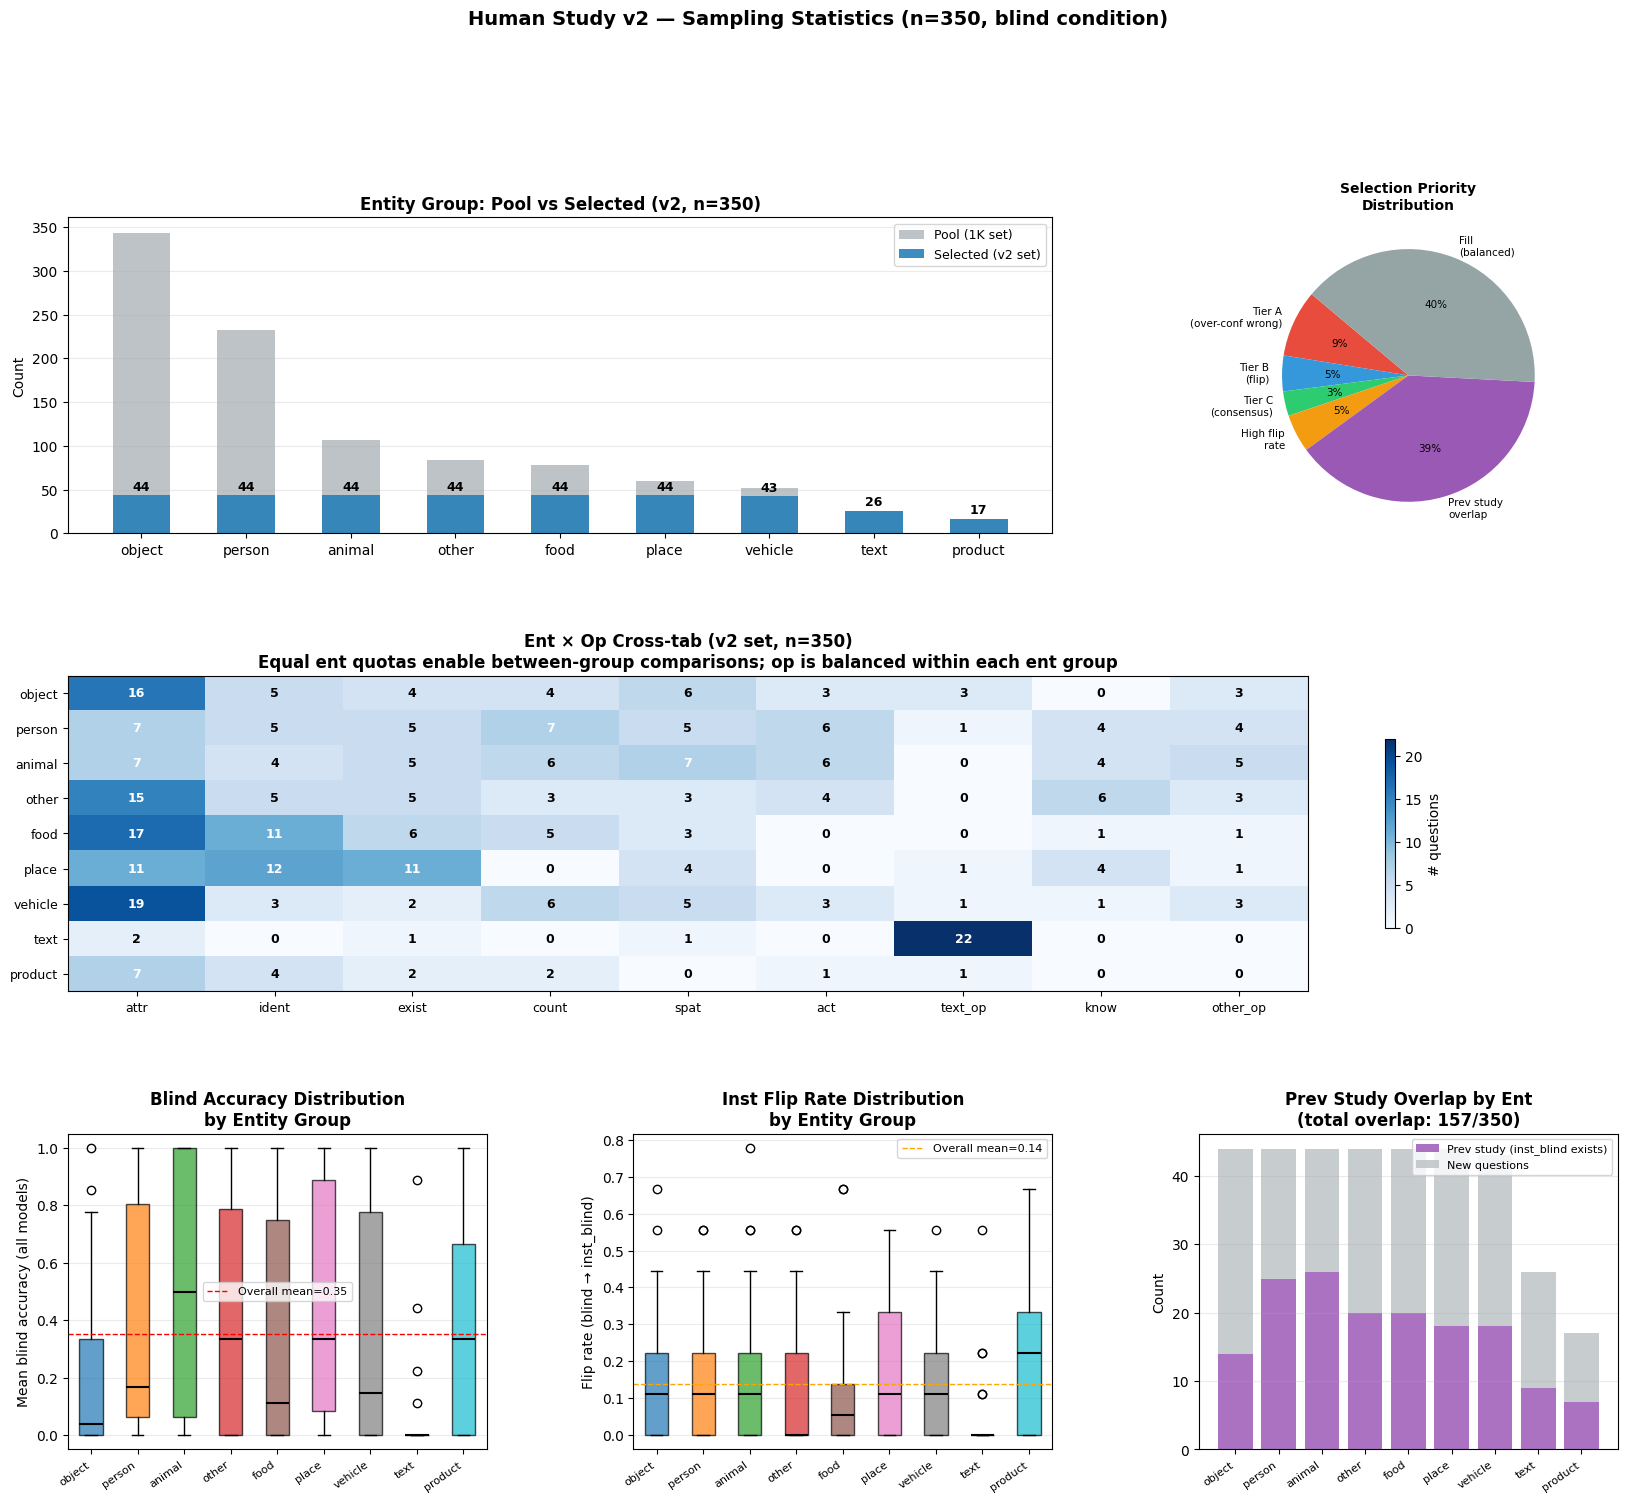

Saved: /home/david/Desktop/yuna/HPA/analysis/figures/v2_sampling_stats.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

ENT_ORDER = ['object', 'person', 'animal', 'other', 'food', 'place', 'vehicle', 'text', 'product']
OP_ORDER  = ['attr', 'ident', 'exist', 'count', 'spat', 'act', 'text_op', 'know', 'other_op']

PRIORITY_COLORS = {
    'tier_A_overconfident_wrong': '#e74c3c',
    'tier_B_answer_flip':         '#3498db',
    'tier_C_consensus_wrong':     '#2ecc71',
    'high_inst_flip_rate':        '#f39c12',
    'prev_study_continuity':      '#9b59b6',
    'fill_balanced':              '#95a5a6',
}

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── (0,0–1) Ent quota bar: selected vs pool ──────────────────────────────────
ax0 = fig.add_subplot(gs[0, :2])
x = np.arange(len(ENT_ORDER))
pool_vals = [sem['ent'].value_counts().get(e, 0) for e in ENT_ORDER]
sel_vals  = [v2['ent'].value_counts().get(e, 0) for e in ENT_ORDER]
ax0.bar(x, pool_vals, color='#bdc3c7', label='Pool (1K set)', width=0.55)
ax0.bar(x, sel_vals,  color='#2980b9', label='Selected (v2 set)', width=0.55, alpha=0.9)
for xi, sv in zip(x, sel_vals):
    ax0.text(xi, sv + 2, str(sv), ha='center', va='bottom', fontsize=9, fontweight='bold')
ax0.set_xticks(x)
ax0.set_xticklabels(ENT_ORDER, fontsize=10)
ax0.set_ylabel('Count')
ax0.set_title('Entity Group: Pool vs Selected (v2, n=350)', fontweight='bold')
ax0.legend(fontsize=9)
ax0.grid(axis='y', alpha=0.25)

# ── (0,2) Priority pie ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 2])
pri_vals   = [v2['selection_reason'].value_counts().get(k, 0) for k in PRIORITY_COLORS]
pri_labels = ['Tier A\n(over-conf wrong)', 'Tier B\n(flip)', 'Tier C\n(consensus)',
              'High flip\nrate', 'Prev study\noverlap', 'Fill\n(balanced)']
pri_colors = list(PRIORITY_COLORS.values())
wedges, texts, autotexts = ax1.pie(
    pri_vals, labels=pri_labels, colors=pri_colors,
    autopct=lambda p: f'{p:.0f}%' if p > 3 else '',
    startangle=140, textprops={'fontsize': 7.5}
)
for at in autotexts:
    at.set_fontsize(7.5)
ax1.set_title('Selection Priority\nDistribution', fontweight='bold', fontsize=10)

# ── (1, full) Ent × Op cross-tab heatmap ────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
ct = v2.groupby(['ent', 'op']).size().unstack(fill_value=0)
ct = ct.reindex(index=[e for e in ENT_ORDER if e in ct.index],
                columns=[o for o in OP_ORDER if o in ct.columns], fill_value=0)
im = ax2.imshow(ct.values, cmap='Blues', aspect='auto')
for r in range(ct.shape[0]):
    for c in range(ct.shape[1]):
        val = ct.values[r, c]
        ax2.text(c, r, str(val), ha='center', va='center',
                 fontsize=9, color='white' if val > 6 else 'black', fontweight='bold')
ax2.set_xticks(range(len(ct.columns)))
ax2.set_xticklabels(ct.columns, fontsize=9)
ax2.set_yticks(range(len(ct.index)))
ax2.set_yticklabels(ct.index, fontsize=9)
ax2.set_title('Ent × Op Cross-tab (v2 set, n=350)\n'
              'Equal ent quotas enable between-group comparisons; '
              'op is balanced within each ent group', fontweight='bold')
plt.colorbar(im, ax=ax2, shrink=0.6, label='# questions')

# ── (2,0) Blind acc distribution by ent ─────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
ent_groups = [v2[v2['ent'] == e]['blind_acc'].dropna().values for e in ENT_ORDER]
bp = ax3.boxplot(ent_groups, patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=1.5))
colors_ent = plt.cm.tab10(np.linspace(0, 1, len(ENT_ORDER)))
for patch, color in zip(bp['boxes'], colors_ent):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_xticks(range(1, len(ENT_ORDER) + 1))
ax3.set_xticklabels(ENT_ORDER, rotation=35, ha='right', fontsize=8)
ax3.set_ylabel('Mean blind accuracy (all models)')
ax3.set_title('Blind Accuracy Distribution\nby Entity Group', fontweight='bold')
ax3.axhline(v2['blind_acc'].mean(), color='red', linestyle='--',
            linewidth=1, label=f'Overall mean={v2["blind_acc"].mean():.2f}')
ax3.legend(fontsize=8)
ax3.grid(axis='y', alpha=0.25)

# ── (2,1) Flip rate distribution by ent ─────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
flip_groups = [v2[v2['ent'] == e]['flip_rate'].dropna().values for e in ENT_ORDER]
bp2 = ax4.boxplot(flip_groups, patch_artist=True, notch=False,
                  medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp2['boxes'], colors_ent):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_xticks(range(1, len(ENT_ORDER) + 1))
ax4.set_xticklabels(ENT_ORDER, rotation=35, ha='right', fontsize=8)
ax4.set_ylabel('Flip rate (blind → inst_blind)')
ax4.set_title('Inst Flip Rate Distribution\nby Entity Group', fontweight='bold')
ax4.axhline(v2['flip_rate'].mean(), color='orange', linestyle='--',
            linewidth=1, label=f'Overall mean={v2["flip_rate"].mean():.2f}')
ax4.legend(fontsize=8)
ax4.grid(axis='y', alpha=0.25)

# ── (2,2) Prev study overlap ─────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 2])
overlap_by_ent = v2.groupby('ent').apply(lambda g: pd.Series({
    'overlap': g['is_prev_study'].sum(),
    'new': (~g['is_prev_study']).sum(),
})).reindex(ENT_ORDER).fillna(0)
x5 = np.arange(len(ENT_ORDER))
ax5.bar(x5, overlap_by_ent['overlap'], color='#9b59b6', label='Prev study (inst_blind exists)', alpha=0.85)
ax5.bar(x5, overlap_by_ent['new'], bottom=overlap_by_ent['overlap'],
        color='#bdc3c7', label='New questions', alpha=0.85)
ax5.set_xticks(x5)
ax5.set_xticklabels(ENT_ORDER, rotation=35, ha='right', fontsize=8)
ax5.set_ylabel('Count')
ax5.set_title(f'Prev Study Overlap by Ent\n'
              f'(total overlap: {v2["is_prev_study"].sum()}/350)', fontweight='bold')
ax5.legend(fontsize=8)
ax5.grid(axis='y', alpha=0.25)

plt.suptitle('Human Study v2 — Sampling Statistics (n=350, blind condition)',
             fontsize=14, fontweight='bold', y=1.01)

out_path = '/home/david/Desktop/yuna/HPA/analysis/figures/v2_sampling_stats.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out_path}")

In [15]:
# ── Power analysis: responses per cell ───────────────────────────────────────
N_RATERS = 25  # target
print(f"=== Statistical Power Estimates (assuming {N_RATERS} raters) ===\n")

print("Per ent group:")
for ent in ENT_ORDER:
    n_q = (v2['ent'] == ent).sum()
    responses = n_q * N_RATERS
    print(f"  {ent:10s}: {n_q:3d} questions × {N_RATERS} raters = {responses:4d} responses")

print()
print("Per op type (merged):")
for op in v2['op'].value_counts().index:
    n_q = (v2['op'] == op).sum()
    responses = n_q * N_RATERS
    print(f"  {op:10s}: {n_q:3d} questions × {N_RATERS} raters = {responses:4d} responses")

print()
print("Paired condition comparison (blind vs inst_blind):")
n_paired = v2['is_prev_study'].sum()
print(f"  {n_paired} questions have inst_blind ratings (from v1 study, n=20 raters)")
print(f"  New blind ratings will use {N_RATERS} raters")
print(f"  → {n_paired} within-question condition pairs available for mixed-effects analysis")

print()
print("Note: text (26Q) and product (17Q) groups are capped at full pool size.")
print("      These groups will have lower power for within-group tests.")
print("      Recommend treating text/product as secondary comparisons.")

=== Statistical Power Estimates (assuming 25 raters) ===

Per ent group:
  object    :  44 questions × 25 raters = 1100 responses
  person    :  44 questions × 25 raters = 1100 responses
  animal    :  44 questions × 25 raters = 1100 responses
  other     :  44 questions × 25 raters = 1100 responses
  food      :  44 questions × 25 raters = 1100 responses
  place     :  44 questions × 25 raters = 1100 responses
  vehicle   :  43 questions × 25 raters = 1075 responses
  text      :  26 questions × 25 raters =  650 responses
  product   :  17 questions × 25 raters =  425 responses

Per op type (merged):
  attr      : 101 questions × 25 raters = 2525 responses
  ident     :  49 questions × 25 raters = 1225 responses
  exist     :  41 questions × 25 raters = 1025 responses
  spat      :  34 questions × 25 raters =  850 responses
  count     :  33 questions × 25 raters =  825 responses
  text_op   :  29 questions × 25 raters =  725 responses
  act       :  23 questions × 25 raters =  575 re